In [1]:
#install.packages("survival")
library(survival)

In [2]:
d <- read.csv("Bank_Attrition.csv", header = TRUE)
summary(d)

   CustomerID        Age           Income          HomeVal      
 Min.   :   1   Min.   :21.0   Min.   : 0.500   Min.   :  1.30  
 1st Qu.: 627   1st Qu.:47.0   1st Qu.: 5.300   1st Qu.: 18.70  
 Median :1253   Median :57.0   Median : 7.500   Median : 22.50  
 Mean   :1253   Mean   :55.5   Mean   : 8.511   Mean   : 27.21  
 3rd Qu.:1879   3rd Qu.:67.0   3rd Qu.:11.500   3rd Qu.: 27.50  
 Max.   :2505   Max.   :77.0   Max.   :15.000   Max.   :150.00  
     Tenure       DirectDeposit         Loan         NumAccounts    
 Min.   : 0.000   Min.   :0.0000   Min.   :0.0000   Min.   : 1.000  
 1st Qu.: 8.646   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.: 2.000  
 Median :14.664   Median :1.0000   Median :0.0000   Median : 3.000  
 Mean   :16.037   Mean   :0.6379   Mean   :0.2527   Mean   : 2.922  
 3rd Qu.:21.736   3rd Qu.:1.0000   3rd Qu.:1.0000   3rd Qu.: 4.000  
 Max.   :59.937   Max.   :1.0000   Max.   :1.0000   Max.   :11.000  
      Dist            MktShare          ChurnTime         Cens

In [3]:
surv.res <- survreg(Surv(ChurnTime, 1-Censored)~.-CustomerID, data=d, dist="weibull")
summary(surv.res)


Call:
survreg(formula = Surv(ChurnTime, 1 - Censored) ~ . - CustomerID, 
    data = d, dist = "weibull")
                  Value Std. Error      z       p
(Intercept)    2.082330   0.056983  36.54 < 2e-16
Age            0.002568   0.000748   3.43  0.0006
Income        -0.008737   0.002682  -3.26  0.0011
HomeVal        0.000507   0.000561   0.90  0.3660
Tenure         0.004110   0.001038   3.96 7.5e-05
DirectDeposit  0.054730   0.021014   2.60  0.0092
Loan          -0.015452   0.028043  -0.55  0.5816
NumAccounts    0.005422   0.008708   0.62  0.5335
Dist          -0.006569   0.011971  -0.55  0.5832
MktShare       0.007986   0.059472   0.13  0.8932
Log(scale)    -0.813206   0.017582 -46.25 < 2e-16

Scale= 0.443 

Weibull distribution
Loglik(model)= -5891.7   Loglik(intercept only)= -5931
	Chisq= 78.55 on 9 degrees of freedom, p= 3.1e-13 
Number of Newton-Raphson Iterations: 7 
n= 2505 


In [4]:
a <- 1/surv.res$scale
a


[1] 2.255127

In [5]:
beta <- -coef(surv.res)*a
beta


(Intercept)           Age        Income       HomeVal        Tenure 
 -4.695917470  -0.005791709   0.019704049  -0.001144367  -0.009267927 
DirectDeposit          Loan   NumAccounts          Dist      MktShare 
 -0.123423346   0.034846367  -0.012227870   0.014813675  -0.018009854

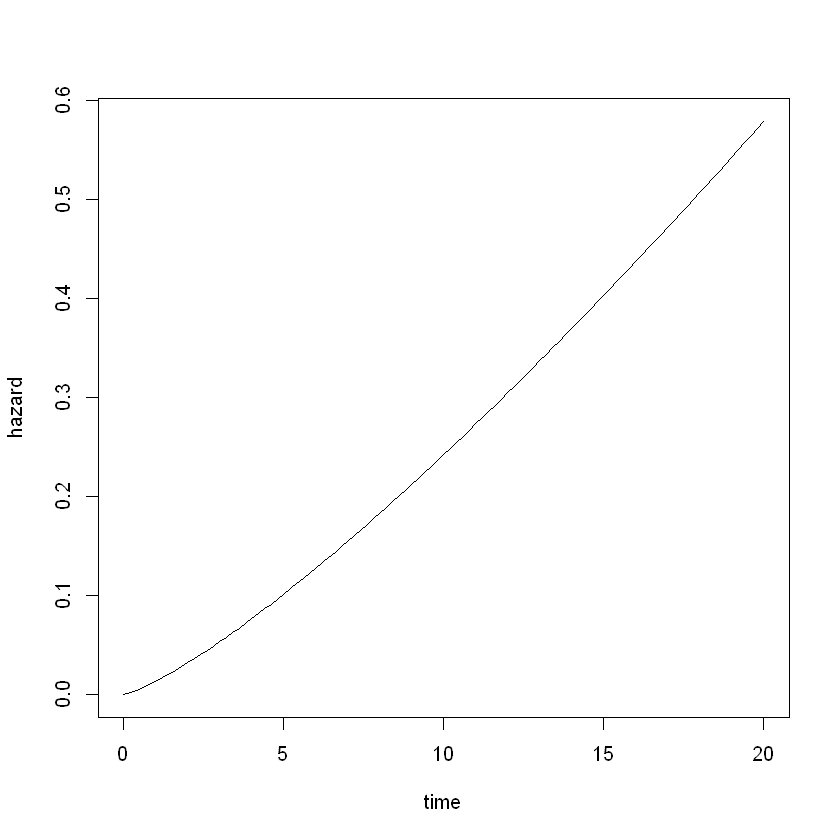

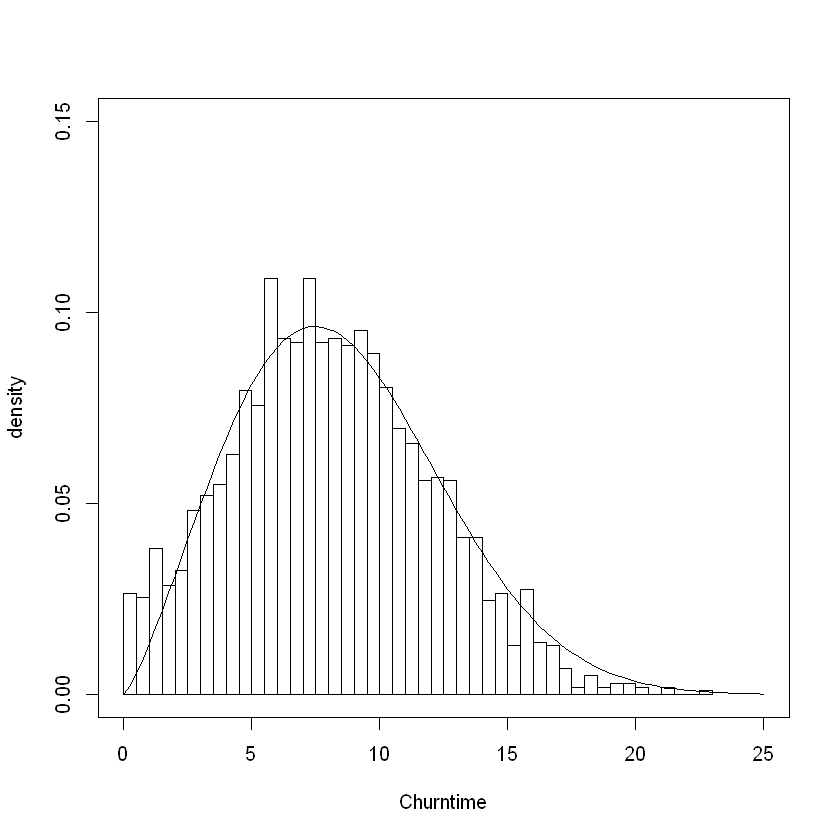

In [28]:
a <- 1/surv.res$scale

beta <- -coef(surv.res)*a

xbar <- colMeans(d[,2:10])
xbeta <- crossprod(c(1,xbar), beta)
curve(exp(c(xbeta))*a*x^(a-1),xlim=c(0,20),xlab = "time", ylab = "hazard")

curve(dweibull(x, shape = a, scale = exp(-xbeta/a)), xlab = "Churntime", ylab="density", xlim=c(0,25), ylim=c(0,0.15))
hist(d$ChurnTime[d$Censored==0], breaks=50, freq = FALSE, add = TRUE, col = NULL) 